In [1]:
# Assingment-08
# Q1.Assingment No. 02

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [18]:
# Task-01

In [19]:
# Task-02

In [20]:
f = pd.read_csv("customer_data_with_clusters.csv")
f

,Age,Annual_Income,Spending_Score,Cluster
0,31,50,42,0
1,69,24,23,3
2,19,28,71,1
3,34,55,57,0
4,56,30,11,3
...,...,...,...,...
95,58,33,21,3
96,45,47,55,0
97,55,82,25,2
98,37,48,55,0


In [21]:
f.head()

,Age,Annual_Income,Spending_Score,Cluster
0,31,50,42,0
1,69,24,23,3
2,19,28,71,1
3,34,55,57,0
4,56,30,11,3


In [22]:
f.shape

(100, 4)

In [23]:
f.describe

<bound method NDFrame.describe of     Age  Annual_Income  Spending_Score  Cluster
0    31             50              42        0
1    69             24              23        3
2    19             28              71        1
3    34             55              57        0
4    56             30              11        3
..  ...            ...             ...      ...
95   58             33              21        3
96   45             47              55        0
97   55             82              25        2
98   37             48              55        0
99   19             27              72        1

[100 rows x 4 columns]>

In [24]:
# Task-03

In [25]:
X = f[["Age", "Annual_Income", "Spending_Score"]]
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [26]:
# Task-04

In [27]:
f["Cluster"] = kmeans.predict(X)
print(f.head(10))
print(f["Cluster"].value_counts().sort_index())

   Age  Annual_Income  Spending_Score  Cluster
0   31             50              42        0
1   69             24              23        3
2   19             28              71        1
3   34             55              57        0
4   56             30              11        3
5   30             59              50        0
6   56             40              30        3
7   54             82              13        2
8   44             86              20        2
9   40            100              28        2
Cluster
0    25
1    25
2    25
3    25
Name: count, dtype: int64


In [28]:
# Task-05

In [29]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Age", "Annual_Income", "Spending_Score"]
)
centers.index.name = "Cluster"
print(centers.round(2))

           Age  Annual_Income  Spending_Score
Cluster                                      
0        36.00          50.20           51.00
1        21.16          21.64           83.08
2        47.88          84.76           19.04
3        62.20          27.28           21.52


In [36]:
# Task-06

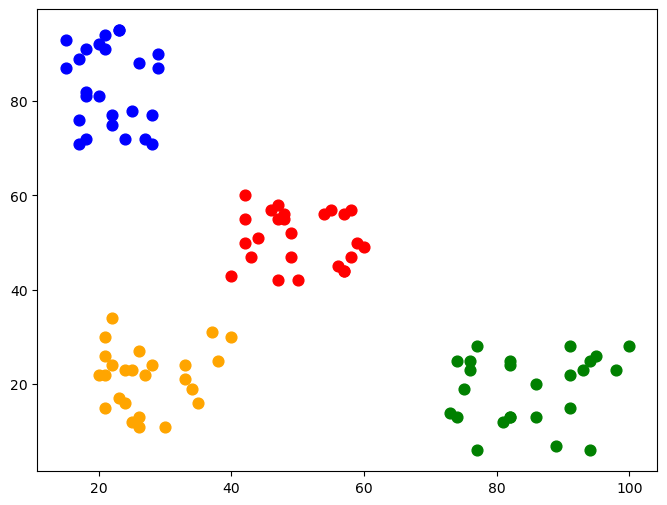

In [42]:
colors = ["red", "blue", "green", "orange"]
plt.figure(figsize=(8, 6))
for cluster_num in range(4):
    cluster_data = f[f["Cluster"] == cluster_num]   
    plt.scatter(
        cluster_data["Annual_Income"],     
        cluster_data["Spending_Score"],    
        s=60,
    color=colors[cluster_num],
        label=f"Cluster {cluster_num}"
    )

Text(0.5, 1.0, 'Customer Segments (Income vs Spending Score)')

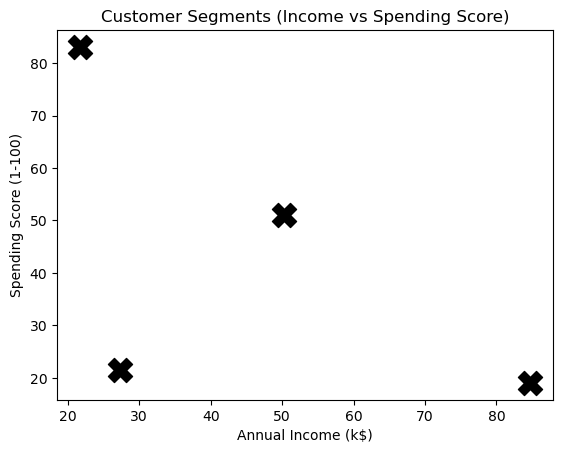

In [41]:
plt.scatter(
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=300, c="black", marker="X", label="Centroids"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (Income vs Spending Score)")

In [43]:
# Task-07

In [48]:
wcss = []
for i in range (1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42
    )
    model.fit(X)
    wcss.append(model.inertia_)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [49]:
wcss

[162610.74,
 76470.19542619541,
 36602.86,
 10592.399999999998,
 9990.185714285713,
 9214.926547619049,
 7997.240573593073,
 6367.326923076923,
 5844.520862470861,
 5093.1794094794095]

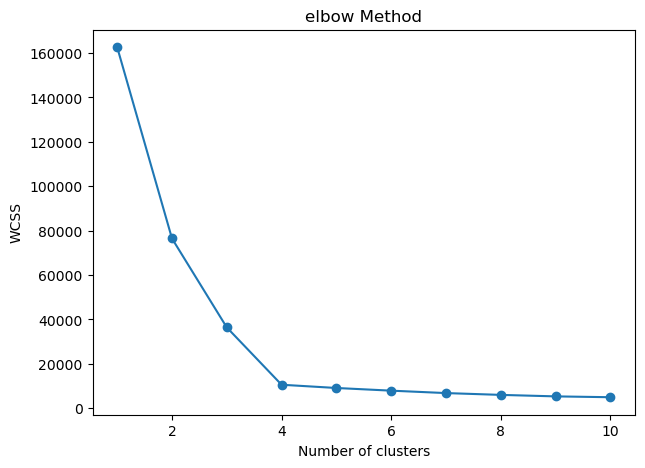

In [45]:
plt.figure(figsize=(7,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("elbow Method")
plt.show()